# Extract Ornaments Data

Extracts OrnamentalBuilding assets and their prestige values from Anno 117
into CSV and JSON files. Output goes to `results/tables/`.

Run all cells from the project root.

## Load assets

Setup game data for processing.

In [1]:
from assetextractor.extraction.utils import Config
from assetextractor.parsing.core.assets import AssetCache

config = Config.from_json("config.json")
assets = AssetCache.load(config)
templates = assets.templates

print(f"Total assets: {len(assets.elements)}")
print(f"Total texts: {len(assets.texts.elements)}")

Total assets: 30719
Total texts: 33191


## Extract the Ornamentals

Extract all the ornaments from `OrnamentalBuilding` (100 assets). The construction group and everything else is handled internally by the extractor.

In [2]:
# Misc: This allow reloading .py modules into jupyter.
%load_ext autoreload
%autoreload 3

In [3]:
from assetextractor.conversion.statistics.ornaments_extractor import OrnamentsExtractor

extractor = OrnamentsExtractor(assets)
# extractor_de = OrnamentsExtractor(assets, language="german")
ornaments_data = extractor.extract_all()

print(f"Processed {len(ornaments_data.keys())} specialists.")

Processed 123 specialists.


## Print Ornaments and their details

Use `extractor.print_ornaments()` to see everything, or `extractor.print_ornaments(guid=80820)` (*"Statue of aLion"* as example) to inspect a specific one.


                             ORNAMENT: Statue of a Lion (GUID: 80820)                               



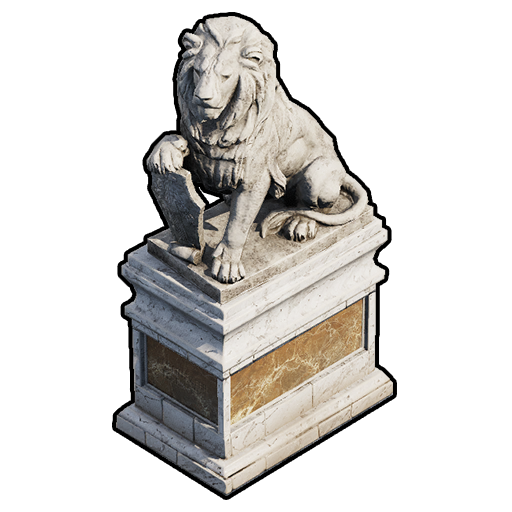

----------------------------------------------------------------------------------------------------
Cost:          10 denarii
Prestige:      1
Unlocked By:   Hall Of Fame


In [4]:
extractor.print_ornaments(guid=80820)

## Export to JSON & Image Export

Using the `save_to_json` method from the extractor. You can pass a custom `web_base_path` to fit your webapp asset structure. If left empty, it will provide the original image game path within the asset extractor.

In [5]:
from pathlib import Path

# Define base output folder
output_root = Path("results")

In [6]:
# =================================================================
# SCENARIO A: MIRRORED STRUCTURE (Mimics Game Folders)
# Use this for: Webapps that need the full "base/icon_content/..." tree.
# =================================================================
print(f" Scenario A: Mirrored ".center(80, "*"))
    
# 1. Export ALL physical files (Icons @ 128px, Big Portraits @ 512px, Small Portraits @ 128px)
# Recreates the game's directory hierarchy for everything.
extractor.export_all_assets(
    output_base=output_root / "icons",
    quality=75,
    flatten=False           # Mirror hierarchy for standard assets & portraits
)

***************************** Scenario A: Mirrored *****************************
Started exporting 149 ornaments icons...
  [OK] -> icons\base\icon_content\infrastructure\icon_3d_quay_0.webp
  [OK] -> icons\base\icon_content\building\icon_3d_construction_category_harbour_0.webp
  [OK] -> icons\base\icon_content\ornaments\icon_3d_wildflowers_white_0.webp
  [OK] -> icons\base\icon_content\ornaments\icon_3d_tree_roman_olive_0.webp
  [OK] -> icons\base\icon_content\generic\icon_2d_generic_item_0.webp
  [OK] -> icons\base\icon_content\infrastructure\icon_3d_construction_category_ornament_0.webp
  [OK] -> icons\base\icon_content\ornaments\icon_3d_shrub_small_0.webp
  [OK] -> icons\base\icon_content\ornaments\icon_3d_shrub_lush_0.webp
  [OK] -> icons\base\icon_content\ornaments\icon_3d_tree_roman_cypress_0.webp
  [OK] -> icons\base\icon_content\ornaments\icon_3d_tree_roman_stout_0.webp
  [OK] -> icons\base\icon_content\ornaments\icon_3d_tree_roman_lush_0.webp
  [OK] -> icons\base\icon_content

In [7]:
# 2. Save JSON with URLs like: "base/icon_content/religion/icon_name.webp"
extractor.save_to_json(
    file_path=output_root / "tables/ornaments_en.json",
    web_base_path="assets/icons",  # No prefix (None) -> relative path from game tree root
    flatten=False             # Matches the mirrored file export paths
)

Successfully exported 123 ornaments to results\tables\ornaments_en.json
Successfully exported 26 categories to results\tables\categories_ornaments_en.json


## Generate Pandas Dataframe Table

In [8]:
import pandas as pd

# 1. Unpack the updated tuple payload (ornaments registry and separate categories metadata)
ornaments_dict, categories_dict = extractor.to_json_dict()

# 2. Load primary ornaments into a base DataFrame
df = pd.DataFrame.from_dict(ornaments_dict, orient='index').reset_index(drop=True)

# 3. Explode 'construction_groups' so ornaments mapped to multiple categories get individual rows
df_flat = df.explode('construction_groups').reset_index(drop=True)

# 4. Normalize the exploded dictionary configurations into clean relational columns
groups_meta = pd.json_normalize(df_flat['construction_groups'])
df_flat = pd.concat([df_flat.drop(columns=['construction_groups']), groups_meta], axis=1)

# 5. Map GUIDs to their localized names using the separate categories lookup dictionary
loc_name_lookup = {guid: meta['localized_name'] for guid, meta in categories_dict.items()}

df_flat['top_localized_name'] = df_flat['top_level_guid'].map(loc_name_lookup)
df_flat['group_localized_name'] = df_flat['construction_group_guid'].map(loc_name_lookup)

# 6. Strategic Column Reordering
# Place the localized hierarchy descriptors at the front for clean visualization
hierarchy_cols = ['top_localized_name', 'group_localized_name', 'top_level_guid', 'construction_group_guid']
other_cols = [col for col in df_flat.columns if col not in hierarchy_cols]

df_flat = df_flat[hierarchy_cols + other_cols]

# --- UPDATED ANALYSIS EXAMPLES ---

# Example A: Prestige summary by the main Root Tab
# Because of explode(), an ornament's prestige counts toward each tab it is placed under
tab_prestige = df_flat.groupby('top_localized_name')['prestige'].sum().sort_values(ascending=False)

# Example B: Deep Dive into a specific Tab
# (Make sure 'Classic' matches one of your localized construction names, e.g., 'Roman Ornaments')
classic_details = df_flat[df_flat['top_localized_name'] == 'Classic'].groupby('group_localized_name').size()

# Example C: Identify PolygonObjects / Free Ornaments
# Deduplicate by 'uid' first so multi-mapped free ornaments don't skew counts
free_ornaments = df_flat[df_flat['cost'] == 0].drop_duplicates(subset=['uid'])

# 7. Final Output Check
print(f"Extracted {df_flat['uid'].nunique()} unique ornaments spanning {len(df_flat)} category assignments.")
print("\n--- Prestige by Main Tab ---")
print(tab_prestige)
print("\n--- Items in 'Classic' Sub-Groups ---")
print(classic_details)

Extracted 123 unique ornaments spanning 884 category assignments.

--- Prestige by Main Tab ---
top_localized_name
Source                      822
Classic                     438
Special                     352
Structures and Buildings    165
Hall Of Fame                145
Sculpture and Statuary       34
Marvellous Mosaics           32
Cosmetic                     32
Rewards                      31
Horticultural Displays       14
Natural Foliage              13
Miscellaneous                 9
Harbour Buildings             0
Ground Patterns               0
Construction                  0
Walls and Hedges              0
Name: prestige, dtype: int64

--- Items in 'Classic' Sub-Groups ---
group_localized_name
Ground Patterns             26
Horticultural Displays      22
Miscellaneous               18
Natural Foliage             26
Sculpture and Statuary      38
Structures and Buildings    38
Walls and Hedges            14
dtype: int64


## Display

In [9]:
from IPython.display import display, HTML

HEADER_BG = "#5F032E"
ROW_BG = "#EBD2B8"
TEXT_COLOR = "#1D000E"

# =========================================================================
#    Group by core ornament fields and join multiple categories together
# =========================================================================
core_columns = ['uid', 'name', 'title', 'description', 'origin', 'prestige', 'cost', 'icon_url']

df_flat = df_flat.groupby(core_columns, as_index=False).agg({
    'top_localized_name': lambda x: ", ".join(x.dropna().unique()),
    'group_localized_name': lambda x: ", ".join(x.dropna().unique())
})

# 6. Strategic Column Reordering
hierarchy_cols = ['top_localized_name', 'group_localized_name']
other_cols = [col for col in df_flat.columns if col not in hierarchy_cols]
df_flat = df_flat[hierarchy_cols + other_cols]

# 1. Prepare display dataframe by removing background technical names/URLs
columns_to_drop = ['name', 'icon_url', 'description']
display_df = df_flat.drop(columns=columns_to_drop, errors='ignore')

display_df = display_df.rename(columns={
    'top_localized_name': 'Category',
    'group_localized_name': 'Sub-Category',
    'uid': 'Asset ID',
    'title': 'Ornament Name',
    'origin': 'Unlock Origin',
    'prestige': 'Prestige',
    'cost': 'Cost (Denarii)'
})
    
# 2. Apply Styling
styled_df = (display_df.style
    .set_properties(**{
        'background-color': ROW_BG,
        'color': TEXT_COLOR,
        'border': f'1px solid {HEADER_BG}',
        'padding': '10px',
        'text-align': 'left'
    })
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', HEADER_BG),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('padding', '12px'),
                ('border', f'1px solid {HEADER_BG}')
            ]
        }
    ])
    .format({
        'Cost (Denarii)': '{:,}',
        'Prestige': '{:,}'
    })
    .hide(axis="index")
)
    
display(styled_df)

Category,Sub-Category,Asset ID,Ornament Name,Unlock Origin,Prestige,Cost (Denarii)
"Harbour Buildings, Construction",Harbour Buildings,41342,Quay,Base,0,20
"Structures and Buildings, Rewards, Source, Classic, Special","Structures and Buildings, Rewards",42197,Tholos,Base,9,"1,000"
"Sculpture and Statuary, Rewards, Source, Classic, Special","Sculpture and Statuary, Rewards",42198,Harmonia,Base,1,200
"Harbour Buildings, Construction",Harbour Buildings,42436,Quay,Base,0,20
"Natural Foliage, Source, Classic",Natural Foliage,80573,Lone Cypress,Base,1,10
"Natural Foliage, Source, Classic",Natural Foliage,80574,Wild Flowers,Base,1,10
"Natural Foliage, Source, Classic",Natural Foliage,80575,Small Shrub,Base,1,10
"Horticultural Displays, Hall Of Fame, Source, Classic, Special","Horticultural Displays, Hall Of Fame",80576,Large Lithophyte,Hall Of Fame,4,10
"Horticultural Displays, Source, Classic",Horticultural Displays,80579,Flower Bed (White),Base,1,20
"Ground Patterns, Hall Of Fame, Source, Classic, Special","Ground Patterns, Hall Of Fame",80590,Cobbled Mosaic,Hall Of Fame,0,0


## Save CSV files

In [10]:
output_dir = Path("results/tables")
output_dir.mkdir(parents=True, exist_ok=True)

df.to_csv(output_dir / "ornaments_en.csv", index=False)

print(f"Saved CSVs to {output_dir.resolve()}")

Saved CSVs to D:\Anno_117_Modding\asset-extractor\assetextractor\conversion\statistics\results\tables
